In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [17]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [18]:
random.randint(140, 195)

177

In [19]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [20]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [52, 42, 52, 40, 53, 43, 59, 64, 67, 47, 62, 54, 41, 60, 42, 46, 47, 69, 61, 70, 48, 54, 47, 56, 44, 52, 68, 66, 69, 65, 54, 60, 41, 66, 53, 40, 69, 56, 66, 68, 40, 61, 41, 45, 68, 64, 61, 62, 45, 66]
여자 키(y축) : [147, 146, 148, 151, 168, 166, 147, 140, 146, 156, 150, 168, 164, 147, 145, 156, 166, 144, 165, 155, 150, 148, 156, 167, 156, 165, 144, 168, 165, 152, 164, 147, 161, 140, 140, 155, 149, 164, 163, 154, 151, 159, 148, 158, 164, 163, 157, 162, 151, 159]
남자 몸무게(x축) : [89, 85, 60, 93, 73, 64, 85, 63, 87, 93, 89, 81, 95, 63, 95, 64, 73, 64, 65, 74, 70, 90, 79, 76, 78, 78, 82, 91, 78, 88, 74, 91, 60, 60, 95, 93, 95, 78, 63, 82, 63, 71, 60, 82, 74, 64, 80, 83, 77, 92]
남자 키(y축) : [185, 167, 187, 186, 193, 172, 167, 176, 171, 175, 186, 183, 164, 187, 168, 182, 190, 195, 174, 170, 165, 188, 194, 174, 182, 165, 161, 184, 162, 169, 172, 183, 165, 181, 176, 165, 184, 169, 175, 176, 179, 192, 171, 189, 191, 167, 186, 181, 188, 184]


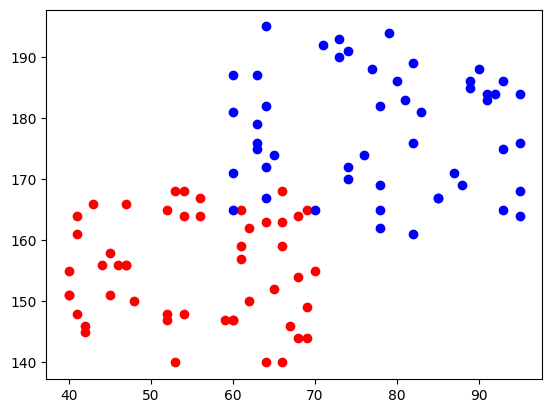

In [21]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [22]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_poinsts[0], random_poinsts[1]

([49, 169], [86, 179])

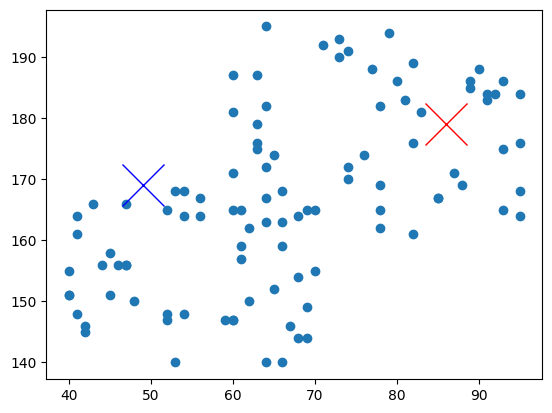

In [23]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b') # 기준점0
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r') # 기준점1

In [24]:
# 두점 거리를 return하는 함수 점은 [50,160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [62]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_poinsts[0], d) < dist(random_poinsts[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(53, 47)

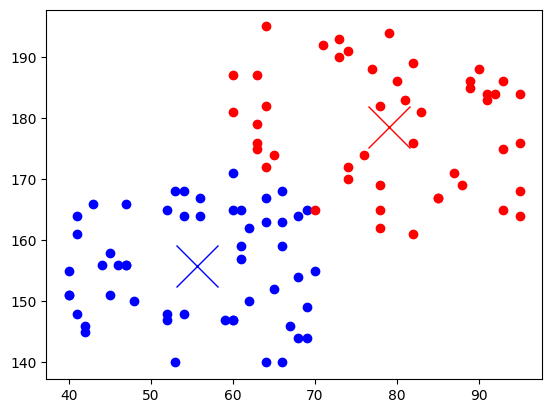

In [63]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

In [64]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_poinsts[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_poinsts[1] = [group1_meanX, group1_meanY]
random_poinsts

[[55.660377358490564, 155.81132075471697],
 [79.1063829787234, 178.5744680851064]]

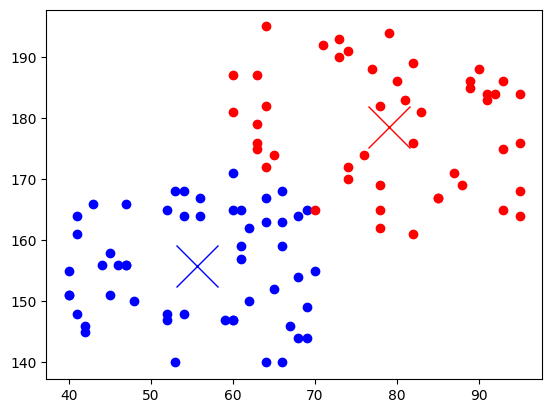

In [65]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

# 3.군집화전체 코드(for문이용) 
- 랜덤포인트 2개지정 - 출력 및 시각화
- for문
    * 랜덤포인트 2지점 기준으로 group0과 group1을 나눔
    * group0의 중간점과 group1의 중간지점을 랜덤포인트로 업데이트
    * 랜덤포인트 출력 및 시각화

초기지점 : [[74, 155], [43, 190]]
1 번째 points : [[67.8452380952381, 163.75], [60.5625, 181.0]]
2 번째 points : [[65.08571428571429, 159.74285714285713], [70.4, 182.3]]
3 번째 points : [[58.40677966101695, 156.61016949152543], [78.58536585365853, 180.7560975609756]]
4 번째 points : [[56.07272727272727, 156.27272727272728], [79.64444444444445, 179.0222222222222]]
5 번째 points : [[55.925925925925924, 155.9814814814815], [79.30434782608695, 178.8695652173913]]
6 번째 points : [[55.660377358490564, 155.81132075471697], [79.1063829787234, 178.5744680851064]]
7 번째 points : [[55.660377358490564, 155.81132075471697], [79.1063829787234, 178.5744680851064]]
8 번째 points : [[55.660377358490564, 155.81132075471697], [79.1063829787234, 178.5744680851064]]
9 번째 points : [[55.660377358490564, 155.81132075471697], [79.1063829787234, 178.5744680851064]]
10 번째 points : [[55.660377358490564, 155.81132075471697], [79.1063829787234, 178.5744680851064]]


(140.0, 195.0)

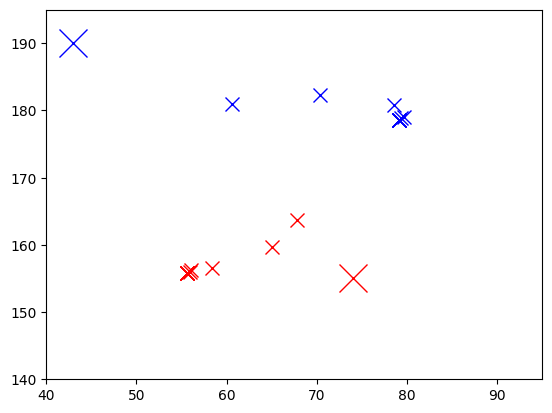

In [73]:
points=[
    [random.randint(40,95),random.randint(140,195)],
    [random.randint(40,95),random.randint(140,195)],    
]
print('초기지점 :',points)
plt.plot(points[0][0],points[0][1],'x',color='r',markersize=20)
plt.plot(points[1][0],points[1][1],'x',color='b',markersize=20)
for i in range(1,11):
    #points 두 지점을 기준으로 group과 group1나누기
    group0=[]
    group1=[]
    for info in data:
        if dist(points[0],info)<dist(points[1],info):
            group0.append(info)
        else:
            group1.append(info)
    #group0의 중간점, group1의 중간점으로 points업데이트
    group0_meanX=np.mean([g[0] for g in group0])
    group0_meanY=np.mean([g[1] for g in group0])
    points[0]=[group0_meanX,group0_meanY]
    
    group1_meanX=np.mean([g[0] for g in group1])
    group1_meanY=np.mean([g[1] for g in group1])
    points[1]=[group1_meanX,group1_meanY]
    
    #업데이트된 points출력 및 시각화
    print(i,'번째 points :',points)
    plt.plot(points[0][0],points[0][1],'x',color='r',markersize=10)
    plt.plot(points[1][0],points[1][1],'x',color='b',markersize=10)
    
plt.xlim([40,95])
plt.ylim([140,195])

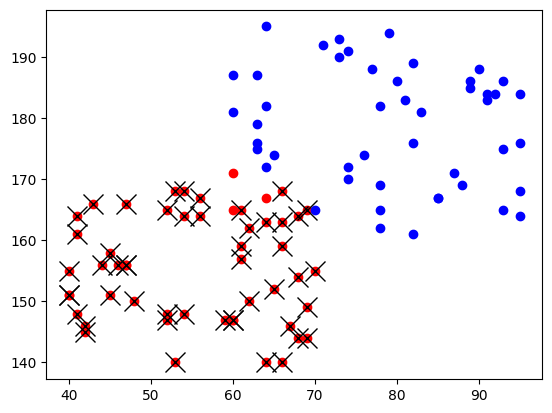

In [78]:
plt.plot([g[0] for g in group0],
        [g[1] for g in group0],'o',color='r')
plt.plot([g[0] for g in group1],
        [g[1] for g in group1],'o',color='b')
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]], 'x',color='k',markersize=15)

# 4. api(sklearn:머신러닝알고리듬)를 이용한 군집화
- sklearn:머신러닝패키지
    *예측/군집모델:회귀분석,분류분석,군집분석 -fit(학습),predict(예측,분류)
    *변환모델:전처리시사용(ex.인코딩,스케일조정,,,문자를숫자로 - fit(학습), transform(변환함수),fit_transform(학습과변환을한꺼번에)

In [79]:
from sklearn.cluster import KMeans
data=np.array(data)#원칙적으로 머신러닝 모델엔 넘파이배열로 학습
model=KMeans(n_clusters=2, #2개 그룹으로 군집화
            init='random', #초기 포인트를 random하게 찍음
            n_init=10,     #10번 실행
            random_state=7)#일관적인 모델을 생성하기 위한 seed값
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [ ]:
# import os
# # os.environ['OMP_NUM_THREADS']='1' ==> 멀티를 못하게 하는 방법
# import warnings
# warnings.filterwarnings(action='ignore')

In [82]:
#두그룹의 기준점:
model.cluster_centers_

array([[ 79.10638298, 178.57446809],
       [ 55.66037736, 155.81132075]])

In [83]:
#나눠진그룹들의 index..0번그룹 1번그룹
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0])

In [84]:
group1=data[model.labels_==1]
group0=data[model.labels_==0]

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True,  True,  True, False,  True, False,  True, False,
        True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True,  True,  True, False,  True, False,
        True,  True,  True, False,  True, False,  True, False,  True,
       False])

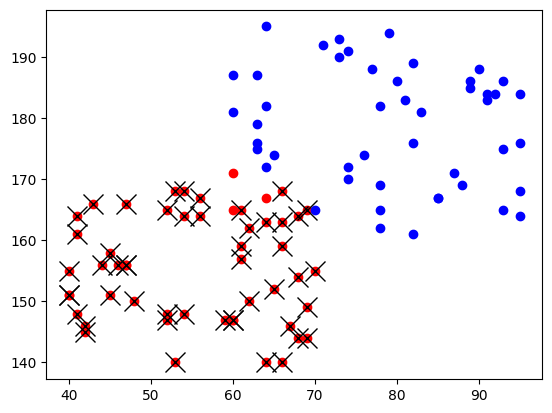

In [86]:
plt.plot([g[0] for g in group0],
        [g[1] for g in group0],'o',color='r')
plt.plot([g[0] for g in group1],
        [g[1] for g in group1],'o',color='b')
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]], 'x',color='k',markersize=15)
plt.show()